# Mental Health Score Predictor

In [202]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

## Data Loading

In [137]:
# load data
df = pd.read_csv('../data/Student Social Media And Mental Health Impact.csv')

In [138]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [139]:
df.sample(10)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
657,21,Male,Other,Undergraduate,Facebook,Networking,5.9,176,2.0,1.6,4.6,Very High,5.2
2899,20,Female,Australia,Undergraduate,Instagram,Entertainment,4.5,141,4.1,1.5,7.4,High,7.4
2122,20,Female,Australia,Undergraduate,Facebook,Networking,5.0,181,3.0,1.2,7.2,High,7.1
598,20,Male,Other,Undergraduate,LinkedIn,Education,7.6,227,1.0,0.7,4.6,Very High,5.0
4209,24,Female,Other,Graduate,Instagram,Entertainment,7.6,237,1.5,0.6,4.6,Very High,5.0
1401,21,Male,Denmark,Undergraduate,Facebook,Networking,3.2,116,5.6,2.4,8.6,Medium,8.0
648,22,Male,India,Undergraduate,Twitter,News,5.5,190,3.1,2.0,7.1,Medium,7.0
2438,18,Male,Other,High School,TikTok,Entertainment,2.0,121,6.3,2.1,8.2,Low,7.1
3591,20,Female,Germany,Undergraduate,TikTok,Entertainment,6.6,206,1.6,1.3,5.0,Very High,4.6
485,23,Male,India,Graduate,Twitter,News,7.2,234,1.4,0.3,5.3,Very High,6.0


In [140]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 507.9 KB


In [141]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [142]:
df.shape

(5000, 13)

In [143]:
df.duplicated().sum()

np.int64(2)

In [144]:
# dropping duplicate vlaues
df.drop_duplicates(inplace=True)

In [145]:
# converting negetive physical activity hr values to zero
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [146]:
df['Country'].value_counts()

Country
Other         1879
India          389
USA            354
Canada         230
Australia      198
              ... 
Montenegro       1
Bosnia           1
Kuwait           1
Yemen            1
Syria            1
Name: count, Length: 111, dtype: int64

## EDA

### Most Used Platform (Count)

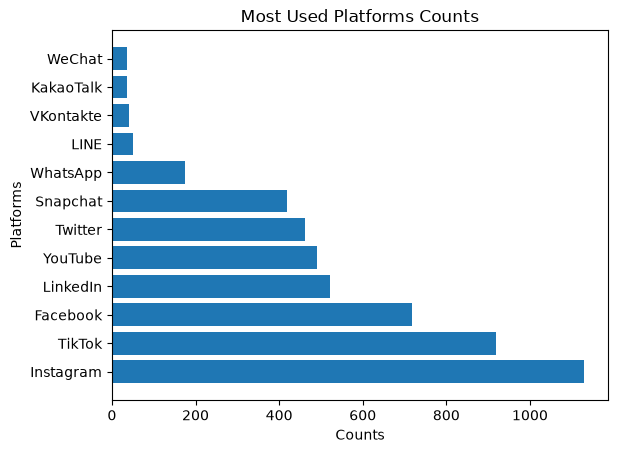

In [147]:
plt.barh(df['Most_Used_Platform'].value_counts().index, width=df['Most_Used_Platform'].value_counts().values)

plt.title('Most Used Platforms Counts')
plt.xlabel('Counts')
plt.ylabel('Platforms')


plt.show()

### Overall Average Usages of Each Platform

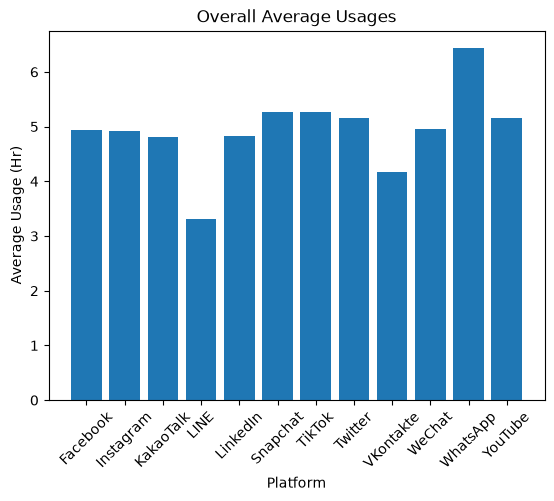

In [148]:
avg_usages = df.groupby('Most_Used_Platform')['Avg_Daily_Usage_Hours'].mean()

plt.bar(x=avg_usages.index, height=avg_usages.values)

plt.title('Overall Average Usages')
plt.xlabel('Platform')
plt.ylabel('Average Usage (Hr)')

plt.xticks(rotation=45)

plt.show()

### Correlation of Numeric Columns

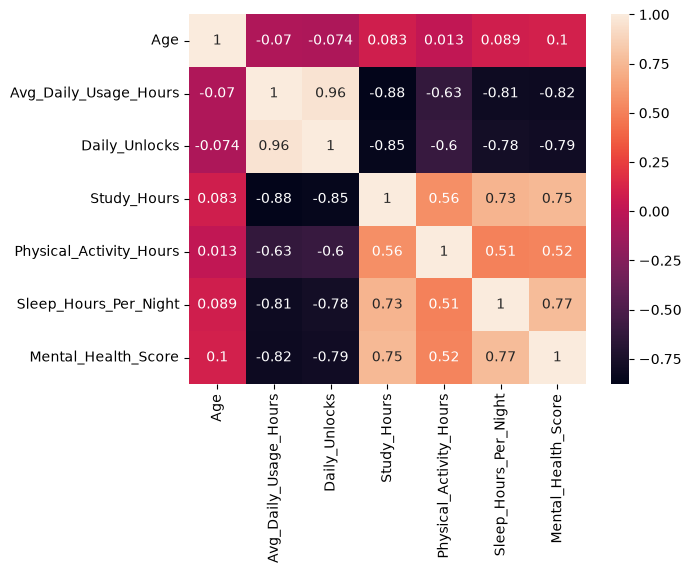

In [149]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

### Mental Health Socre vs Average Daily Usage (hr)

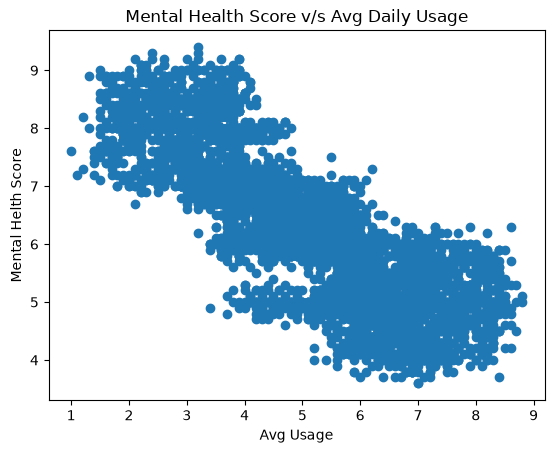

In [150]:
plt.scatter(x=df['Avg_Daily_Usage_Hours'], y=df['Mental_Health_Score'])

plt.title('Mental Health Score v/s Avg Daily Usage')
plt.xlabel('Avg Usage')
plt.ylabel('Mental Helth Score')

plt.show()

### Study Hr v/s Mental Health Score

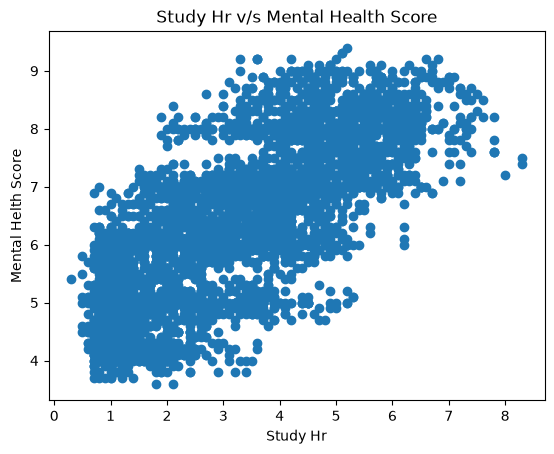

In [151]:
plt.scatter(x=df['Study_Hours'], y=df['Mental_Health_Score'])

plt.title('Study Hr v/s Mental Health Score')
plt.xlabel('Study Hr')
plt.ylabel('Mental Helth Score')

plt.show()

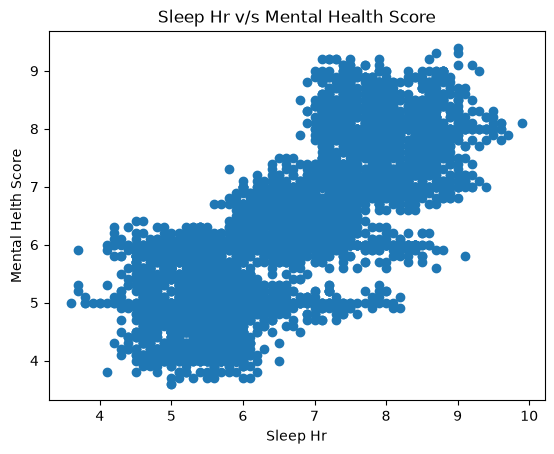

In [152]:
plt.scatter(x=df['Sleep_Hours_Per_Night'], y=df['Mental_Health_Score'])

plt.title('Sleep Hr v/s Mental Health Score')
plt.xlabel('Sleep Hr')
plt.ylabel('Mental Helth Score')

plt.show()

### Stress Level v/s Mental Health Score

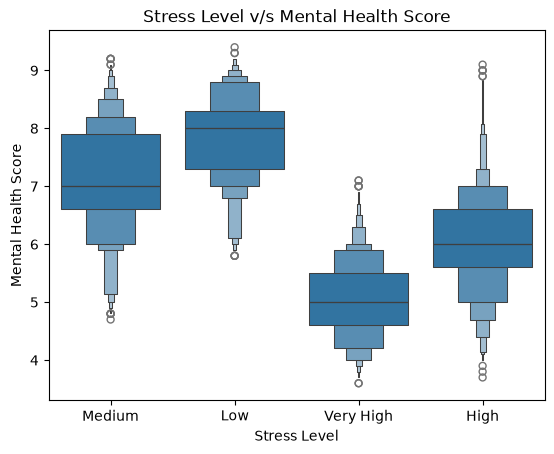

In [153]:
sns.boxenplot(x=df['Stress_Level'], y=df['Mental_Health_Score'])

plt.title('Stress Level v/s Mental Health Score')
plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')

plt.show()

### Academic Level v/s Mental Health Score

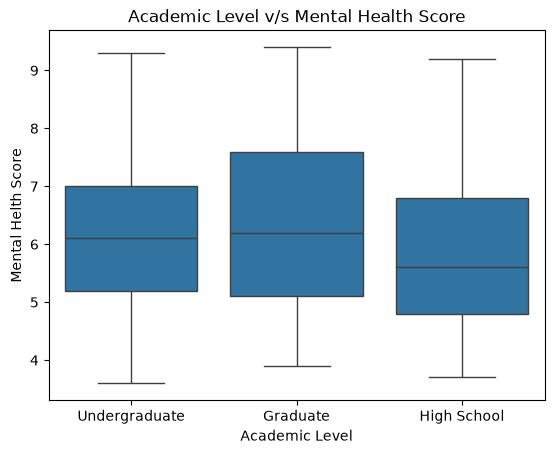

In [154]:
sns.boxplot(x=df['Academic_Level'], y=df['Mental_Health_Score'])

plt.title('Academic Level v/s Mental Health Score')
plt.xlabel('Academic Level')
plt.ylabel('Mental Helth Score')

plt.show()

### Distribution of Mental Health Score

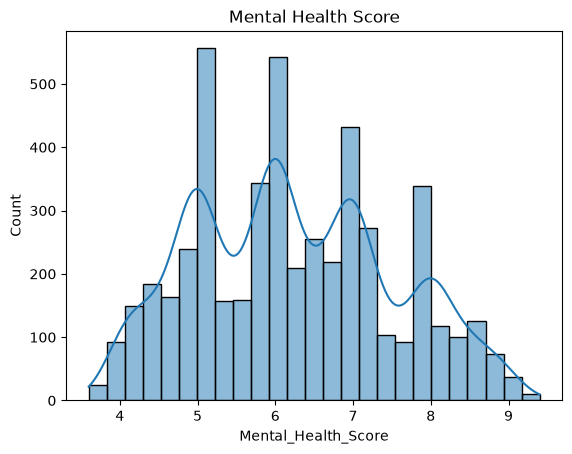

In [155]:
sns.histplot(df['Mental_Health_Score'], kde=True)

plt.title('Mental Health Score')

plt.show()

### Skewness

In [156]:
print(df.skew(numeric_only=True))
numeric_cols = df.select_dtypes(include='number').columns[:6]

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64


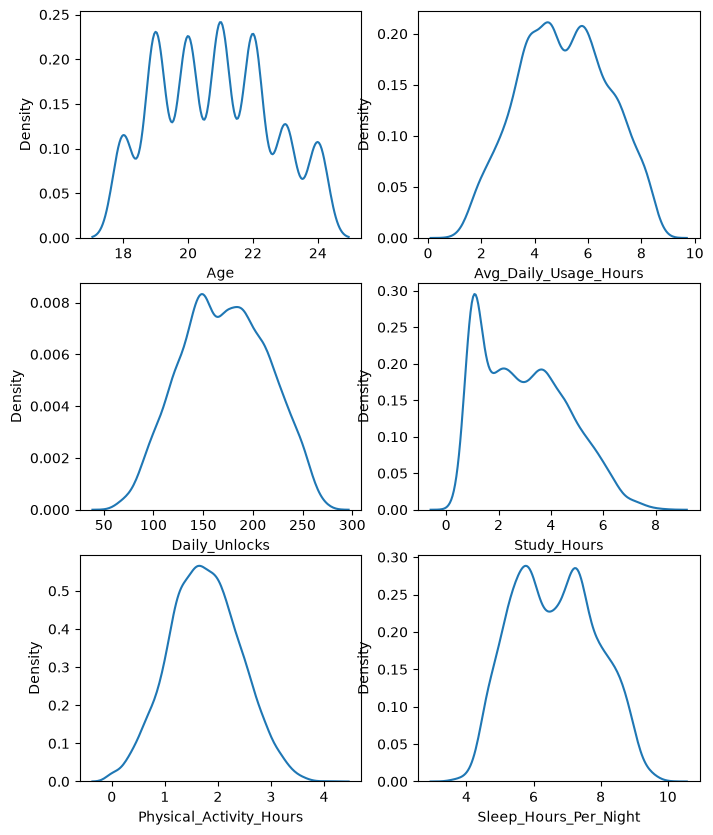

In [157]:
fig, axes = plt.subplots(3, 2, figsize=(8, 10))
axes=axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.kdeplot(df[col], ax=ax)


## Preprocessing

In [158]:
# Dropping Country, Country of use
df.drop(columns=['Country', 'Purpose_Of_Use'], inplace=True)

In [ ]:
# Encoding

encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])
df[['Stress_Level']] = encoder.fit_transform(df[['Stress_Level']])

In [160]:
df['Gender'] = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit_transform(df[['Gender']]) # male-0, female-1

In [161]:
encoder = OrdinalEncoder(categories=[['High School', 'Undergraduate', 'Graduate']])
df[['Academic_Level']] = encoder.fit_transform(df[['Academic_Level']])

In [164]:
encode = OrdinalEncoder()
df[['Most_Used_Platform']] = encode.fit_transform(df[['Most_Used_Platform']])
print(encode.categories_)

[array(['Facebook', 'Instagram', 'KakaoTalk', 'LINE', 'LinkedIn',
       'Snapchat', 'TikTok', 'Twitter', 'VKontakte', 'WeChat', 'WhatsApp',
       'YouTube'], dtype=object)]


In [174]:
# Skewness of study hr
print(df['Study_Hours'].skew(), np.log1p(df['Study_Hours']).skew(), sep='\n')
df['Study_Hours'] = np.log1p(df['Study_Hours'])

0.4361245948820438
-0.13437069104348032


In [189]:
df.columns

Index(['Age', 'Gender', 'Academic_Level', 'Most_Used_Platform',
       'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Stress_Level',
       'Mental_Health_Score'],
      dtype='str')

In [199]:
# Scaling Numerical Columns
x, y = df.iloc[:,0:10], df.iloc[:,-1]

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

scale = StandardScaler()
x_train_transform = scale.fit_transform(x_train)
x_test_transform = scale.transform(x_test)

## Model Training

### Linear Regression

In [205]:
lr = LinearRegression()
lr.fit(x_train_transform, y_train)

print('r2 score on training data : ', r2_score(y_train, lr.predict(x_train_transform)))
print('r2 score on testing data : ', r2_score(y_test, lr.predict(x_test_transform)))

print('MAE on training data : ', mean_absolute_error(y_test, lr.predict(x_test_transform)))

r2 score on training data :  0.7040003137069837
r2 score on testing data :  0.7246667465280874
MAE on training data :  0.5530155480105067
